<a href="https://colab.research.google.com/github/Tahmidro/phitronNotebooks/blob/main/phitron_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##module 1 EDA part 1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:

df=pd.read_csv("titanic_data_updated.csv")
print(f"total number of potential feature:{df.shape[1]}")
print(f"total number of sample:{df.shape[0]}")
##df.head(10)  for fiirst 10 rows
df.sample(10)##for 10 random sample across the dataset so we can get the better insight of the dataset


total number of potential feature:12
total number of sample:891


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
575,576,no,third,"Patchett, Mr. George",male,19.0,0,0,358585,14.5000,NaN,S
180,181,no,third,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.5500,NaN,S
827,828,yes,second,"Mallet, Master. Andre",male,1.0,0,2,S.C./PARIS 2079,37.0042,NaN,C
220,221,yes,third,"Sunderland, Mr. Victor Francis",male,16.0,0,0,SOTON/OQ 392089,8.0500,NaN,S
421,422,no,third,"Charters, Mr. David",male,21.0,0,0,A/5. 13032,7.7333,NaN,Q
19,20,yes,third,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
260,261,no,third,"Smith, Mr. Thomas",male,NaN,0,0,384461,7.7500,NaN,Q
249,250,no,second,"Carter, Rev. Ernest Courtenay",male,54.0,1,0,244252,26.0000,NaN,S
262,263,no,first,"Taussig, Mr. Emil",male,52.0,1,1,110413,79.6500,E67,S
782,783,no,first,"Long, Mr. Milton Clyde",male,29.0,0,0,113501,30.0000,D6,S


In [ ]:
#missing values
display(df.isnull().sum())##isnull functions returns colimn wise there missing value or not by bool.
#so summing them returns count of missing values column wise.

##checking duplicates and deleting them
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


0


In [ ]:
df.info()
###from here we can understand the dataframe info by columns
##like how much values in each features,missing values yes or not,
#datatype of each column

#for getting a statistical idea about dataframe
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


##univariate analysis

<Axes: xlabel='Survived', ylabel='count'>

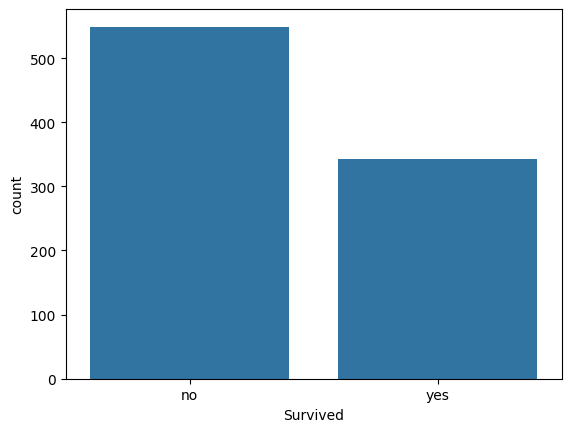

In [ ]:
##count plot of survived

sns.countplot(data=df,x=df["Survived"])
##from where we can know that model can be biased to not survived

Survived
no     61.616162
yes    38.383838
Name: count, dtype: float64


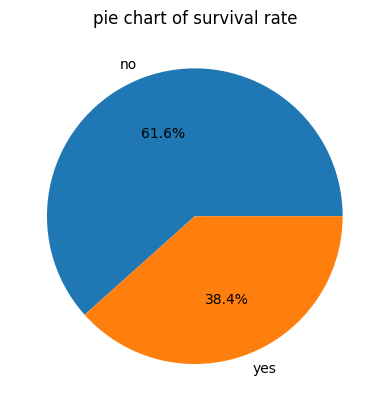

In [ ]:
##pie chart
countSurvived=(df['Survived'].value_counts()/len(df))*100
print(countSurvived)
survivedLabels=df["Survived"].unique()
plt.pie(countSurvived,labels=survivedLabels,autopct="%1.1f%%")
plt.title("pie chart of survival rate")
plt.show()

##univariate analysis for numerical value

<Axes: xlabel='Fare', ylabel='Count'>

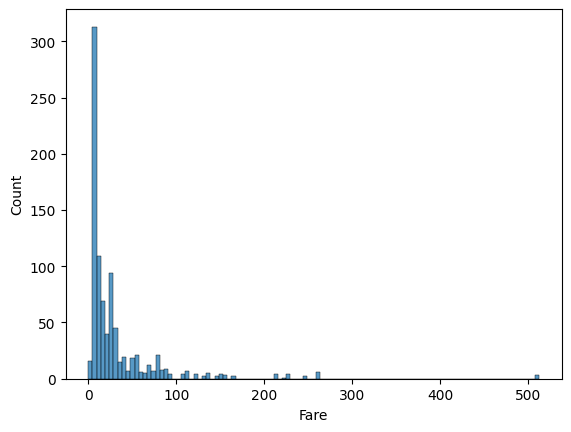

In [ ]:
sns.histplot(df["Fare"])

<Axes: xlabel='Fare', ylabel='Density'>

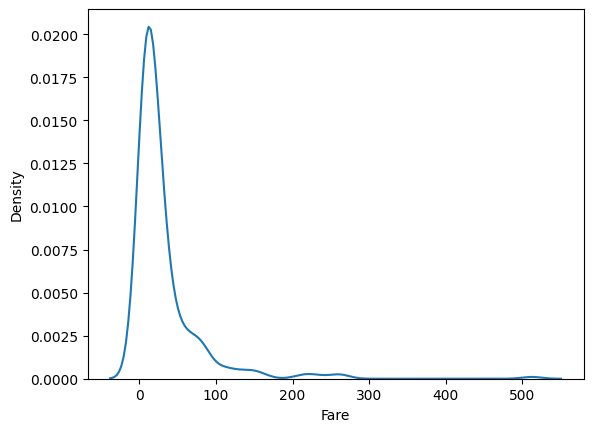

In [ ]:
sns.kdeplot(df['Fare'])##for outlier detection

module 1 practice

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
penguins = sns.load_dataset('penguins')

In [ ]:
#task1

print(f"total number of potential feature:{penguins.shape[1]}")
print(f"total number of sample:{penguins.shape[0]}")
penguins.head(7)
penguins.sample(6)


total number of potential feature:7
total number of sample:344


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
282,Gentoo,Biscoe,45.7,13.9,214.0,4400.0,Female
72,Adelie,Torgersen,39.6,17.2,196.0,3550.0,Female
18,Adelie,Torgersen,34.4,18.4,184.0,3325.0,Female
129,Adelie,Torgersen,44.1,18.0,210.0,4000.0,Male
283,Gentoo,Biscoe,54.3,15.7,231.0,5650.0,Male
220,Gentoo,Biscoe,46.1,13.2,211.0,4500.0,Female


In [ ]:
#task2
display(penguins.isnull().sum().sort_values(ascending=False).index[0])##showing which column has the most null values


'sex'

In [ ]:
#task3
penguins.duplicated().sum()
penguins.drop_duplicates(inplace=True)

In [ ]:
#task4
penguins.info()
penguins.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


<Axes: xlabel='species', ylabel='count'>

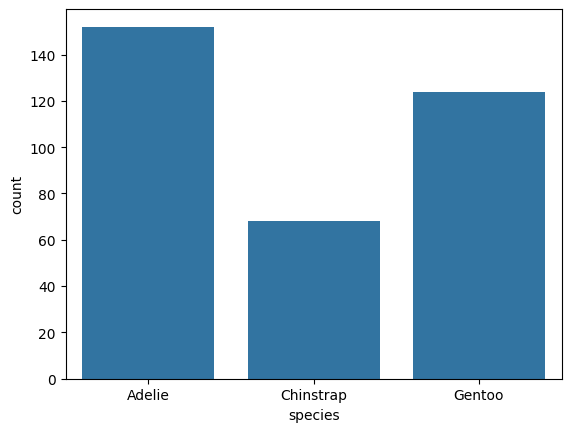

In [ ]:
#task five

sns.countplot(data=penguins,x=penguins["species"])

In [ ]:
#task 6
penguinsInisland=(penguins['island'].value_counts())
print(penguinsInisland)


island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64


sex
Male      48.837209
Female    47.965116
Name: count, dtype: float64


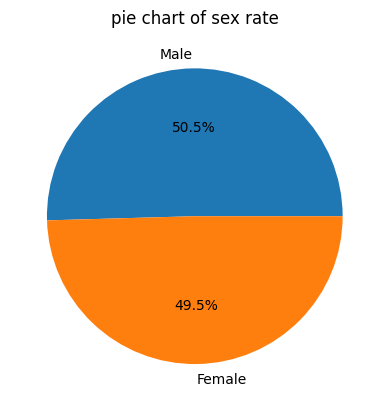

In [ ]:
sexp=(penguins["sex"].value_counts()/len(penguins["sex"]))*100
print(sexp)
sexLabels=sexp.index
plt.pie(sexp,labels=sexLabels,autopct="%1.1f%%")
plt.title("pie chart of sex rate")
plt.show()

##module 2 EDA part 2

<Axes: xlabel='Survived', ylabel='count'>

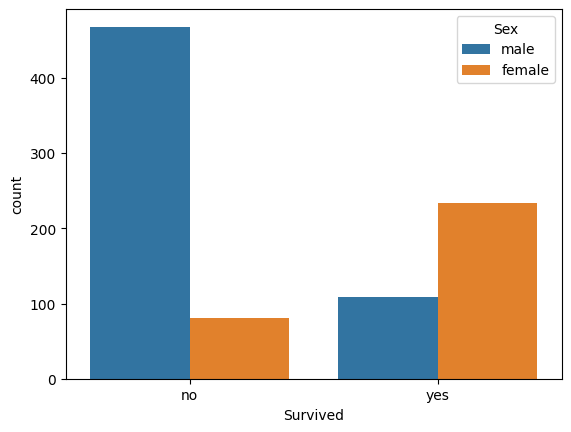

In [ ]:
sns.countplot(x=df["Survived"],hue=df["Sex"])

In [ ]:
genderSplit=df.groupby("Sex")["Survived"].value_counts(normalize=True)##normalize is used for percentage
print(genderSplit)

Sex     Survived
female  yes         0.742038
        no          0.257962
male    no          0.811092
        yes         0.188908
Name: proportion, dtype: float64


##y data profiling


In [ ]:
pip install ydata_profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.3 MB/s eta 0:00:00


In [ ]:
from ydata_profiling import ProfileReport

/tmp/ipykernel_4726/44057814.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [ ]:
profile=ProfileReport(df,title="MyTitanicDataProile")
profile.to_file("MyTitanicDataProile.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 17.60it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

#module 3 train test split

feature engineering
basic drop columns

In [ ]:
df.drop(["PassengerId","Name","Ticket"],axis=1,inplace=True)##axis is for columns

In [ ]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,NaN,S
887,yes,first,female,19.0,0,0,30.0000,B42,S
888,no,third,female,NaN,1,2,23.4500,NaN,S
889,yes,first,male,26.0,0,0,30.0000,C148,C


In [ ]:
df.drop(["Cabin"],axis=1,inplace=True)

In [ ]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,no,third,male,22.0,1,0,7.2500,S
1,yes,first,female,38.0,1,0,71.2833,C
2,yes,third,female,26.0,0,0,7.9250,S
3,yes,first,female,35.0,1,0,53.1000,S
4,no,third,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,S
887,yes,first,female,19.0,0,0,30.0000,S
888,no,third,female,NaN,1,2,23.4500,S
889,yes,first,male,26.0,0,0,30.0000,C


target column and target data selection

In [ ]:
X=df.drop(["Survived"],axis=1)
Y=df["Survived"]
display(X.head())
display(Y.head())

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,third,male,22.0,1,0,7.2500,S
1,first,female,38.0,1,0,71.2833,C
2,third,female,26.0,0,0,7.9250,S
3,first,female,35.0,1,0,53.1000,S
4,third,male,35.0,0,0,8.0500,S


,Survived
0,no
1,yes
2,yes
3,yes
4,no


In [ ]:
xtrain,xtest,ytrain,ytest=train_test_split(X,Y,test_size=0.2,random_state=42)


In [ ]:
display(xtrain)
display(xtest)
display(ytrain)
display(ytest)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,first,male,45.5,0,0,28.5000,S
733,second,male,23.0,0,0,13.0000,S
382,third,male,32.0,0,0,7.9250,S
704,third,male,26.0,1,0,7.8542,S
813,third,female,6.0,4,2,31.2750,S
...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,S
270,first,male,NaN,0,0,31.0000,S
860,third,male,41.0,2,0,14.1083,S
435,first,female,14.0,1,2,120.0000,S


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
709,third,male,NaN,1,1,15.2458,C
439,second,male,31.0,0,0,10.5000,S
840,third,male,20.0,0,0,7.9250,S
720,second,female,6.0,0,1,33.0000,S
39,third,female,14.0,1,0,11.2417,C
...,...,...,...,...,...,...,...
433,third,male,17.0,0,0,7.1250,S
773,third,male,NaN,0,0,7.2250,C
25,third,female,38.0,1,5,31.3875,S
84,second,female,17.0,0,0,10.5000,S


,Survived
331,no
733,no
382,no
704,no
813,no
...,...
106,yes
270,no
860,no
435,yes


,Survived
709,yes
439,no
840,no
720,yes
39,yes
...,...
433,no
773,no
25,yes
84,yes


##MOdule 6


Outlier handling using z score


In [ ]:
##zscore calculation
meanAge=xtrain['Age'].mean()
stdAge=xtrain['Age'].std()

xtrain["zscoreAge"]=(xtrain['Age']-meanAge)/stdAge
xtrain.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,zscoreAge
331,first,male,45.5,0,0,28.5000,S,1.103523
733,second,male,23.0,0,0,13.0000,S,-0.448194
382,third,male,32.0,0,0,7.9250,S,0.172493
704,third,male,26.0,1,0,7.8542,S,-0.241299
813,third,female,6.0,4,2,31.2750,S,-1.620603


In [ ]:
##outler detection

outliers=xtrain[abs(xtrain["zscoreAge"])>3]

print(len(outliers))

display(outliers)

2


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,zscoreAge
630,first,male,80.0,0,0,30.000,S,3.482824
851,third,male,74.0,0,0,7.775,S,3.069033


outlier detection by IQR

In [ ]:
Q1ofAge=xtrain['Age'].quantile(0.25)
Q3ofAge=xtrain['Age'].quantile(0.75)

IQRofAge=Q3ofAge-Q1ofAge

minimumAge=Q1ofAge-1.5*IQRofAge
maximumAge=Q3ofAge+1.5*IQRofAge

print(minimumAge,maximumAge)

-4.5 63.5


In [ ]:
outlier=xtrain[(xtrain['Age']<minimumAge) | (xtrain['Age']>maximumAge)]
print(outlier)

     Pclass   Sex   Age  SibSp  Parch     Fare Embarked  zscoreAge
456   first  male  65.0      0      0   26.550        S   2.448345
116   third  male  70.5      0      0    7.750        Q   2.827654
745   first  male  70.0      1      1   71.000        S   2.793172
630   first  male  80.0      0      0   30.000        S   3.482824
851   third  male  74.0      0      0    7.775        S   3.069033
438   first  male  64.0      1      4  263.000        S   2.379380
672  second  male  70.0      0      0   10.500        S   2.793172
